## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

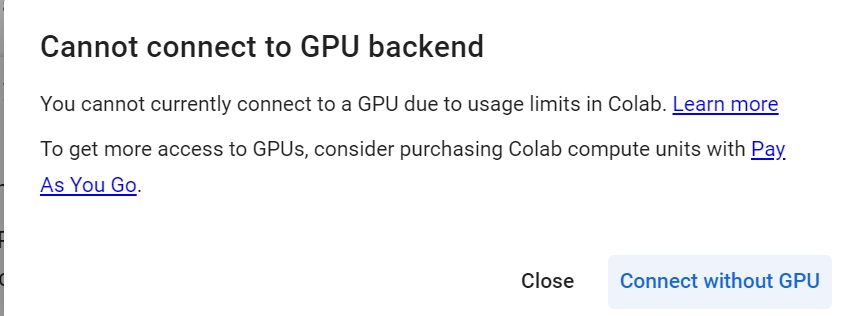

## Installing and Importing Necessary Libraries and Dependencies

In [5]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
# !CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 176.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 129.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 294.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 294.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 275.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.3 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_ver

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [6]:
# For installing the libraries & downloading models from HF Hub
!pip install huggingface_hub==0.23.2 pandas==1.5.3 tiktoken==0.6.0 pymupdf==1.25.1 langchain==0.1.1 langchain-community==0.0.13 chromadb==0.4.22 sentence-transformers==2.3.1 numpy==1.25.2 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [74]:
#Libraries for downloading and loading the llm
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

## Question Answering using LLM

### Downloading and Loading the model

In [75]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [76]:
model_path = hf_hub_download(
    repo_id= "TheBloke/Mistral-7B-Instruct-v0.2-GGUF", #Complete the code to mention the repo id
    filename= "mistral-7b-instruct-v0.2.Q6_K.gguf" #Complete the code to mention the model name
)

In [33]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path,
    n_ctx=2300,
    n_gpu_layers=38,
    n_batch=512
)

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [ ]:
#uncomment the below snippet of code if the runtime is connected to CPU only.
#llm = Llama(
#    model_path=model_path,
#    n_ctx=1024,
#    n_cores=-2
#)

### Response

In [77]:
def response(query,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    model_output = llm(
      prompt=query,
      max_tokens=max_tokens,
      temperature=temperature,
      top_p=top_p,
      top_k=top_k
    )

    return model_output['choices'][0]['text']

In [ ]:
response("What treatment options are available for managing hypertension?")

'\n\nHypertension, or high blood pressure, is a common condition that can increase the risk of various health problems such as heart disease, stroke, and kidney damage. The good news is that there are several effective treatment options available to help manage hypertension and reduce the risk of complications. Here are some of the most commonly used treatments:\n\n1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, whole grains, and lean proteins; limiting sodium intake; getting regular physical activity'

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\n\nSepsis is a life-threatening condition that can arise from an infection, and it requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care unit:\n\n1. Early recognition: Recognize the signs and symptoms of sepsis early and initiate treatment as soon as possible. Sepsis can present with various clinical features, including fever or hypothermia, tachycardia or bradycardia, altered mental status, respiratory distress, and lactic acidosis.\n2. Resusc'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to define the query #2
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ located in the lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but some common signs include:\n\n1. Abdominal pain: The pain may start as a mild discomfort around the navel or in the lower right abdomen, which then gradually moves to the right lower quadrant and becomes more severe over time. The pain may be constant or intermittent and is often worsened by movement, coughing, or deep breathing'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to define the query #3
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nSudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, or eyelashes.\n\nThe exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications."

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to define the query #4
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nA person who has sustained a physical injury to brain tissue, also known as a traumatic brain injury (TBI), may require various treatments depending on the severity and location of the injury. Here are some common treatments recommended for TBIs:\n\n1. Emergency care: The first priority is to ensure the person's airway is clear, they are breathing, and their heart is beating normally. In severe cases, emergency surgery may be required to remove hematomas or other obstructions.\n2. Medications: Depending on the symptoms, medications may be prescribed to manage conditions such as"

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to define the query #5
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nFirst and foremost, if you suspect that someone has fractured their leg while hiking, it's essential to ensure their safety and prevent further injury. Here are some necessary precautions:\n\n1. Keep the person calm and still: Encourage them to remain as still as possible to minimize pain and prevent worsening the injury.\n2. Assess the situation: Check for any signs of shock, such as pale skin, rapid heartbeat, or shallow breathing. If you notice these symptoms, seek medical help immediately.\n3. Immobilize the leg: Use a splint, sl"

## Question Answering using LLM with Prompt Engineering

In [ ]:
system_prompt = "You are a medical reference assistant. Answer questions based only on the provided model_path and filename. If the answer is not found in the manual, say you don't know instead of guessing."
#Complete the code to define the system prompt

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = system_prompt+"\n"+ "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\nI cannot provide an answer to that question based solely on the given model_path and filename. The provided information does not contain sufficient details about sepsis management protocols in a critical care unit.'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ located in the lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but some common signs include:\n\n1. Abdominal pain: The pain is typically located in the lower right quadrant of the abdomen and may start as a mild discomfort that gradually worsens over time. The pain may be constant or intermittent and may be aggravated by movement, deep breathing, or coughing.\n2. Loss of appetite'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nSudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, or eyelashes.\n\nThe exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications."

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nA person who has sustained a physical injury to brain tissue, also known as a traumatic brain injury (TBI), may require various treatments depending on the severity and location of the injury. Here are some common treatments recommended for TBIs:\n\n1. Emergency care: The first priority is to ensure the person's airway is clear, they are breathing, and their heart is beating normally. In severe cases, emergency surgery may be required to remove hematomas or other obstructions.\n2. Medications: Depending on the symptoms, medications may be prescribed to manage conditions such as"

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nFirst and foremost, if you suspect that someone has fractured their leg while hiking, it's essential to ensure their safety and prevent further injury. Here are some necessary precautions:\n\n1. Keep the person calm and still: Encourage them to remain as still as possible to minimize pain and prevent worsening the injury.\n2. Assess the situation: Check for any signs of shock, such as pale skin, rapid heartbeat, or shallow breathing. If you notice these symptoms, seek medical help immediately.\n3. Immobilize the leg: Use a splint, sl"

## Data Preparation for RAG

In [4]:
#Libraries for processing dataframes,text
import json,os
import tiktoken
import pandas as pd

#Libraries for Loading Data, Chunking, Embedding, and Vector Databases
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

In [3]:
!pip install langchain_community

### Loading the Data

In [5]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
manual_pdf_path = "/content/drive/My Drive/medical_diagnosis_manual.pdf" #Complete the code to define the file name

In [7]:
pdf_loader = PyMuPDFLoader(manual_pdf_path)

In [9]:
manual = pdf_loader.load()

In [8]:
!pip install pymupdf

### Data Overview

#### Checking the first 5 pages

In [10]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(manual[i].page_content,end="\n")

Page Number : 1
iannalvita@gmail.com
DNWYB4ACJ1
eant for personal use by iannalvita@gm
shing the contents in part or full is liable
Page Number : 2
iannalvita@gmail.com
DNWYB4ACJ1
This file is meant for personal use by iannalvita@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 3
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    .......................................................................................................................................................................................................
2
Front Matter    ...........................................................................................................................................................................................
53
1

#### Checking the number of pages

In [11]:
len(manual)

4114

### Data Chunking

In [102]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=900,
    chunk_overlap=150
)

In [103]:
document_chunks = pdf_loader.load_and_split(text_splitter)

In [104]:
len(document_chunks)

5486

In [105]:
document_chunks[0].page_content

'iannalvita@gmail.com\nDNWYB4ACJ1\neant for personal use by iannalvita@gm\nshing the contents in part or full is liable'

In [106]:
document_chunks[2].page_content

"Table of Contents\n1\nFront    ................................................................................................................................................................................................................\n1\nCover    .......................................................................................................................................................................................................\n2\nFront Matter    ...........................................................................................................................................................................................\n53\n1 - Nutritional Disorders    ...............................................................................................................................................................\n53\nChapter 1. Nutrition: General Considerations    ...........................................................................................

In [107]:
document_chunks[3].page_content

'491\nChapter 44. Foot & Ankle Disorders    .....................................................................................................................................\n502\nChapter 45. Tumors of Bones & Joints    ...............................................................................................................................\n510\n5 - Ear, Nose, Throat & Dental Disorders    ..................................................................................................................\n510\nChapter 46. Approach to the Patient With Ear Problems    ...........................................................................................\n523\nChapter 47. Hearing Loss    .........................................................................................................................................................\n535\nChapter 48. Inner Ear Disorders    ...................................................................................................

As expected, there are some overlaps

### Embedding

In [108]:
from langchain_community.embeddings import SentenceTransformerEmbeddings

embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

In [109]:
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)

In [110]:
print("Dimension of the embedding vector ",len(embedding_1))
len(embedding_1)==len(embedding_2)

Dimension of the embedding vector  384


True

In [111]:
embedding_1,embedding_2

([-0.06471027433872223,
  0.07040785998106003,
  0.04206308349967003,
  -0.0477403849363327,
  0.0680835023522377,
  -0.02513027936220169,
  0.06571924686431885,
  0.0742170661687851,
  0.0015462706796824932,
  -0.03295014426112175,
  0.06295005977153778,
  -0.02100341208279133,
  0.011617837473750114,
  -0.03609389811754227,
  -0.057025711983442307,
  -0.09166914969682693,
  -0.06000688672065735,
  0.0146322725340724,
  -0.09074307978153229,
  0.027749748900532722,
  -0.05100389942526817,
  -0.00818608608096838,
  -0.009336055256426334,
  -0.012427804060280323,
  -0.008076772093772888,
  0.03672495111823082,
  -0.01966814696788788,
  0.05467032641172409,
  0.0015224110102280974,
  -0.07012846320867538,
  0.04547509178519249,
  -0.04771033301949501,
  0.04580112174153328,
  0.006292018573731184,
  0.04238678514957428,
  0.054948512464761734,
  -0.07290101796388626,
  -0.05737815052270889,
  -0.030807381495833397,
  -0.04712582379579544,
  -0.026482537388801575,
  -0.035684168338775635,

### Vector Database

In [112]:
out_dir = 'medical_db'

if not os.path.exists(out_dir):
  os.makedirs(out_dir)

In [89]:
from langchain.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=document_chunks,
    persist_directory="medical_db",
    embedding=embedding_model
)

In [20]:
!pip install chromadb

In [120]:
vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)

In [91]:
vectorstore.embeddings

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [24]:
vectorstore.similarity_search("What are the recommended treatments for hypertension?",k=5) #Complete the code to pass a query and an appropriate k value

[Document(metadata={'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'keywords': '', 'creationDate': 'D:20120615054440Z', 'creationdate': '2012-06-15T05:44:40+00:00', 'author': '', 'modDate': 'D:20250911233017Z', 'moddate': '2025-09-11T23:30:17+00:00', 'format': 'PDF 1.7', 'trapped': '', 'page': 2230, 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'file_path': '/content/drive/My Drive/medical_diagnosis_manual.pdf', 'source': '/content/drive/My Drive/medical_diagnosis_manual.pdf', 'total_pages': 4114, 'creator': 'Atop CHM to PDF Converter', 'subject': ''}, page_content="Chapter 208. Arterial Hypertension\nIntroduction\nHypertension is sustained elevation of resting systolic BP (≥ 140 mm Hg), diastolic BP (≥ 90 mm\nHg), or both. Hypertension with no known cause (primary; formerly, essential hypertension) is\nmost common. Hypertension with an identified cause (secondary hypertension) is usually due\nto a renal disorder. Usually, no symptoms develop unless hyp

### Retriever

In [25]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 3} #Complete the code to pass an appropriate k value
)

In [27]:
rel_docs = retriever.get_relevant_documents("What are the treatment options for hypertension?") #Complete the code to pass the query
rel_docs

/tmp/ipython-input-4213983356.py:1: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  rel_docs = retriever.get_relevant_documents("What are the treatment options for hypertension?") #Complete the code to pass the query


[Document(metadata={'moddate': '2025-09-11T23:30:17+00:00', 'total_pages': 4114, 'file_path': '/content/drive/My Drive/medical_diagnosis_manual.pdf', 'format': 'PDF 1.7', 'author': '', 'trapped': '', 'creationDate': 'D:20120615054440Z', 'modDate': 'D:20250911233017Z', 'creationdate': '2012-06-15T05:44:40+00:00', 'keywords': '', 'subject': '', 'creator': 'Atop CHM to PDF Converter', 'source': '/content/drive/My Drive/medical_diagnosis_manual.pdf', 'page': 2230, 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)'}, page_content="Chapter 208. Arterial Hypertension\nIntroduction\nHypertension is sustained elevation of resting systolic BP (≥ 140 mm Hg), diastolic BP (≥ 90 mm\nHg), or both. Hypertension with no known cause (primary; formerly, essential hypertension) is\nmost common. Hypertension with an identified cause (secondary hypertension) is usually due\nto a renal disorder. Usually, no symptoms develop unless hyp

In [118]:
model_output = llm(
      "What are the treatment options for hypertension?", #Complete the code to pass the query
      max_tokens=512, temperature=0.2
    )

Llama.generate: prefix-match hit


In [119]:
model_output['choices'][0]['text']

"\n\nHypertension, or high blood pressure, is a common condition that can lead to serious health problems if left untreated. The good news is that there are several effective treatment options available.\n\n1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, and whole grains; limiting sodium intake; getting regular physical activity; maintaining a healthy weight; and reducing stress.\n2. Medications: If lifestyle modifications aren't enough to control your blood pressure, your doctor may prescribe medication. There are several different types of medications used to treat hypertension, including diuretics, beta blockers, ACE inhibitors, calcium channel blockers, and ARBs (angiotensin receptor blockers).\n3. Complementary therapies: Some complementary therapies may help lower blood pressure, although more research is needed to confirm their effectiveness. These inc

The above response is somewhat generic and is solely based on the data the model was trained on, rather than the medical manual.  

Let's now provide our own context.

### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [113]:
qna_system_message = "You are a helpful medical reference assistant. Use only the provided context from the medical_diagnosis_manual.pdf to answer questions. If the answer is not in the document, say 'I don’t know' instead of guessing. Provide clear, accurate, and concise explanations."

In [114]:
qna_user_message_template = "Answer the following question using the provided context:\n\nQuestion: {question}\n\nContext:\n{context}"

### Response Function

In [141]:
def generate_rag_response(user_input,k=3,max_tokens=200,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    prompt = qna_system_message + '\n' + user_message

    # Generate the response
    try:
        response = llm(
                  prompt=prompt,
                  max_tokens=max_tokens,
                  temperature=temperature,
                  top_p=top_p,
                  top_k=top_k
                  )

        # Extract and print the model's response
        response = response['choices'][0]['text'].strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [142]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
generate_rag_response(user_input,top_k=20)

Llama.generate: prefix-match hit


'the amount that could be disseminated.\nPrevention and Control\nThe best way to prevent or control an outbreak of biological warfare is to prevent it from occurring.\nThis can be accomplished by international cooperation and diplomacy, as well as by strengthening\nnational security measures. In the event of a suspected attack, the following steps should be taken:\n1. Identify the agent (or agents) involved. This may require laboratory analysis of samples obtained\nfrom victims or from'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [122]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'In patients with atypical or equivocal findings, imaging studies should be done without delay. Contrast-\nenhanced CT has reasonable accuracy in diagnosing appendicitis and can also reveal other causes of an\nacute abdomen. Graded compression ultrasound can usually be done quickly and uses no radiation (of\nparticular concern in children); however, it is occasionally limited by the presence of bowel gas and is less\nuseful for recognizing nonappendiceal causes of pain. Appendicitis remains primarily a clinical diagnosis.\nSelective and judicious use of radiographic studies'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [123]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'corticosteroids, retinoids, or immunosuppressants.\nHair loss due to chemotherapy is temporary and is best treated with a wig; when hair regrows, it may be\ndifferent in color and texture from the original hair. Hair loss due to telogen effluvium or anagen effluvium\nis usually temporary as well and abates after the precipitating agent is eliminated.\n\nAnswer:\nSudden patchy hair loss, commonly seen as localized bald spots on the scalp, could be a symptom of alopecia areata'

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [124]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"Answer: For a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function, early intervention by rehabilitation specialists is essential for maximal functional recovery. Treatments include prevention of secondary disabilities such as pressure ulcers, joint contractures, and pneumonia, as well as cognitive therapy for severe cognitive dysfunction. Physical and occupational therapy may modestly improve functioning but is more often useful for making the environment safer and providing devices to help patients circumvent primary deficits. The specific rehabilitation therapy varies depending on the patient's abnormalities,"

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [125]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
generate_rag_response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'thigh sleeve. Elevation above the level of the heart decreases edema and pain.\n\nAnswer: For a person who has fractured their leg during a hiking trip, necessary precautions include preventing Deep Vein Thrombosis (DVT) by encouraging them to walk or move their legs periodically if they are at higher risk. Treatment steps involve rest, ice, compression, and elevation of the affected leg using a thigh sleeve. Pain can be managed with NSAIDs and analgesics as necessary, and crutches may be required initially for walking. For severe injuries,'

### Fine-tuning

#### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [126]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
generate_rag_response(user_input,temperature=0.5)

Llama.generate: prefix-match hit


'the amount that could be produced. Anthrax is generally considered unlikely to cause widespread panic\nbecause it usually produces symptoms only in those who have inhaled large amounts of spores and are\nexposed for several hours or days. In addition, anthrax can be treated with antibiotics if diagnosed early.\nBotulinum toxin is a neurotoxin that causes flaccid paralysis by inhibiting the release of acetylcholine from\nmot'

#### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [127]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
generate_rag_response(user_input_2) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


'In patients with atypical or equivocal findings, imaging studies should be done without delay. Contrast-\nenhanced CT has reasonable accuracy in diagnosing appendicitis and can also reveal other causes of an\nacute abdomen. Graded compression ultrasound can usually be done quickly and uses no radiation (of\nparticular concern in children); however, it is occasionally limited by the presence of bowel gas and is less\nuseful for recognizing nonappendiceal causes of pain. Appendicitis remains primarily a clinical diagnosis.\nSelective and judicious use of radiographic studies'

#### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [129]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
generate_rag_response(user_input_2) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


'corticosteroids, retinoids, or immunosuppressants.\nHair loss due to chemotherapy is temporary and is best treated with a wig; when hair regrows, it may be\ndifferent in color and texture from the original hair. Hair loss due to telogen effluvium or anagen effluvium\nis usually temporary as well and abates after the precipitating agent is eliminated.\n\nAnswer:\nSudden patchy hair loss, commonly seen as localized bald spots on the scalp, could be a symptom of alopecia areata'

#### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [130]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
generate_rag_response(user_input_2) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


"Answer: For a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function, early intervention by rehabilitation specialists is essential for maximal functional recovery. Treatments include prevention of secondary disabilities such as pressure ulcers, joint contractures, and pneumonia, as well as cognitive therapy for severe cognitive dysfunction. Physical and occupational therapy may modestly improve functioning but is more often useful for making the environment safer and providing devices to help patients circumvent primary deficits. The specific rehabilitation therapy varies depending on the patient's abnormalities,"

#### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [131]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
generate_rag_response(user_input_2) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


'thigh sleeve. Elevation above the level of the heart decreases edema and pain.\n\nAnswer: For a person who has fractured their leg during a hiking trip, necessary precautions include preventing Deep Vein Thrombosis (DVT) by encouraging them to walk or move their legs periodically if they are at higher risk. Treatment steps involve rest, ice, compression, and elevation of the affected leg using a thigh sleeve. Pain can be managed with NSAIDs and analgesics as necessary, and crutches may be required initially for walking. For severe injuries,'

## Output Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation.

- We are using the same Mistral model for evaluation, so basically here the llm is rating itself on how well he has performed in the task.

In [132]:
groundedness_rater_system_message = (
    "You are an evaluator. Your task is to rate how well the assistant’s answer is grounded in the provided context. If the answer is fully supported by the context, mark it as grounded. If parts of the answer are unsupported, speculative, or contradictory, mark it as not grounded. Do not add extra details—just evaluate groundedness."
) #Complete the code to define the prompt to evaluate groundedness

In [133]:
relevance_rater_system_message = (
    "You are an evaluator. Your task is to judge how relevant the retrieved context is to the user’s question. If the context directly supports answering the question, rate it as relevant. If it is only loosely connected, off-topic, or irrelevant, rate it as not relevant. Do not invent new information."
)


In [134]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [139]:
def generate_ground_relevance_response(user_input,k=3,max_tokens=200,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=3)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)

    # Combine user_prompt and system_message to create the prompt
    prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_input)}
                [/INST]"""

    response = llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    answer =  response["choices"][0]["text"]

    # Combine user_prompt and system_message to create the prompt
    groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    # Combine user_prompt and system_message to create the prompt
    relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    response_1 = llm(
            prompt=groundedness_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    response_2 = llm(
            prompt=relevance_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    return response_1['choices'][0]['text'],response_2['choices'][0]['text']

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [154]:
ground,rel = generate_ground_relevance_response(user_input="What is the protocol for managing sepsis in a critical care unit?",max_tokens=72)

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 ground

 Based on the user's question about the protocol for managing


### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [144]:
ground,rel = generate_ground_relevance_response(user_input="What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?",max_tokens=200) #Complete the code to pass the query #2 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 The answer is grounded as it accurately summarizes the common symptoms of appendicitis from the context and correctly states that it cannot be

 The context is highly relevant to the user's question as it provides detailed information about the common symptoms of appendicitis and confirms that treatment for appendicitis involves surgical removal


### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [145]:
ground,rel = generate_ground_relevance_response(user_input="What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?",max_tokens=200) #Complete the code to pass the query #3 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 The assistant's answer is grounded in the context as it correctly identifies alopecia areata as a cause of sudden patchy hair loss and mentions various treatment options such as topical, intralesional, or systemic corticosteroids, topical minoxidil, topical anthralin, topical immunotherapy (diphencyprone or squaric acid dibutylester), or psoralen plus ultraviolet A (PUVA) that are consistent with the context.

 Relevant. The context provides detailed information about the causes and treatments of alopecia areata, which is a type of sudden patchy hair loss that matches the user's question.


### Query 4: What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [146]:
ground,rel = generate_ground_relevance_response(user_input="What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?",max_tokens = 200) #Complete the code to pass the query #4 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Grounded. The answer accurately summarizes the treatments recommended for a person with a brain injury based on the information provided in the context.

 Relevant. The context provides detailed information about the recommended treatments for a person with a brain injury, including early intervention by rehabilitation specialists, prevention of secondary disabilities, physical and occupational therapy, cognitive therapy, and family education.


### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [147]:
ground,rel = generate_ground_relevance_response(user_input="What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?",max_tokens = 200) #Complete the code to pass the query #5 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 The answer is grounded in the context provided. It correctly identifies the risk of DVT for someone with a fractured leg and recommends preventive measures based on the information given about different treatment options for DVT prevention. Additionally, it mentions the initial care steps of rest, ice, and compression, which are also mentioned in the context.

 (NSAIDs) and analgesics may be prescribed for pain relief, and crutches might be necessary if walking is painful.

3. Further treatment: Depending on the severity of the injury, splinting or casting might be required to prevent further injury and decrease pain. In some cases, definitive treatment like reduction (realignment of the bone) may be necessary, which usually requires analgesia or sedation. Closed reduction is maintained by casting, while open reduction is maintained by surgical hardware such as pins, screws, plates, or external fixators.

4. Prevention and recognition of complications: It's essential to recognize and 

## Actionable Insights and Business Recommendations


*   
*  
*



<font size=6 color='blue'>Power Ahead</font>
___